# Lab 2 : Generation Of Random Number Using PseudoRandom & Chi-Square Test

## Objectives

1. To understand the concept of random numbers and the two key conditions they must satisfy — uniform distribution over a defined interval and unpredictability of future values based on past or present values.
2. To study common algorithms used for random number generation, with focus on the **Linear Congruential Generator (LCG)** method.
3. To implement a Pseudo Random Number Generator using the LCG formula without relying on built-in library functions, and to compute the seed/state manually.
4. To validate the randomness of the generated numbers using the **Chi-Square Test** by comparing observed and expected frequencies.

## Theory

**Random Number**
A random number is a sequence of numbers chosen by chance, satisfying two main conditions:
- The values are uniformly distributed over a defined interval.
- It is impossible to predict a future value based on past or present values.

**Real-World Applications**
Random numbers are widely used in Cryptography, Machine Learning, and Simulation.

**Algorithms to Generate Random Numbers**
- Linear Congruential Generator (LCG)
- XOR Shift Generator
- Mersenne Twister

**Linear Congruential Generator (LCG)**
LCG is simple to implement and requires minimal memory, making it fast and efficient.

$$
X_{n+1} = (a \cdot X_n + c) \mod m
$$

Where:

| Symbol | Condition | Meaning |
|--------|-----------|---------|
| $m$ | $0 < m$ | Modulus |
| $a$ | $0 < a < m$ | Multiplier |
| $c$ | $0 \le c < m$ | Increment |
| $X_0$ | $0 \le X_0 < m$ | Seed / start value |

**Chi-Square Test**
Used to test the goodness of fit of the generated random numbers (i.e., whether they follow a uniform distribution).

$$
\chi^2 = \sum_{i=0}^{n} \frac{(O_i - E_i)^2}{E_i}
$$

Where:

| Symbol | Meaning |
|--------|---------|
| $O_i$ | Observed frequency |
| $E_i$ | Expected frequency |
| $n$ | Number of intervals/observations |

## Random State / Seed

The **seed** ($X_0$) is the initial value given to a pseudo-random number generator. Since generators like LCG are fully deterministic, the seed determines the entire sequence of numbers produced the same seed will always generate the same sequence. The **random state** refers to the current value ($X_n$) held by the generator at any point, which is used to compute the next number in the sequence.

## Methodology

To generate a seed **without using any built-in random library**, the seed is derived manually from the system clock, since system time changes continuously and provides unpredictable input.

**Steps:**
1. Read the current system time components: Hour (H), Minute (M), Second (S), Millisecond (MS).
2. Combine these components arithmetically into a single large number.
3. Reduce (fold) this number into the valid seed range using modulus with $m$.
4. Use the resulting value as $X_0$, the starting state for the LCG.

## Computation of Seed (without library) — Detailed

**Step 1: Read system time**

| Component | Value |
|-----------|-------|
| Hour (H) | 13 |
| Minute (M) | 42 |
| Second (S) | 7 |
| Millisecond (MS) | 583 |

**Step 2: Combine into raw number**

$$
\text{raw} = (H \times 3600 + M \times 60 + S) \times 1000 + MS
$$

$$
\text{raw} = (13 \times 3600 + 42 \times 60 + 7) \times 1000 + 583
$$

$$
\text{raw} = (46800 + 2520 + 7) \times 1000 + 583
$$

$$
\text{raw} = 49327 \times 1000 + 583 = 49327583
$$

**Step 3: Fold into seed range** (assume $m = 100000$)

$$
X_0 = 49327583 \bmod 100000 = 27583
$$

**Step 4: Seed obtained**

$$
X_0 = 27583
$$

This value is now used as the starting input for the LCG recurrence:

$$
X_{n+1} = (a \cdot X_n + c) \bmod m
$$

No random/library function is used anywhere  the seed is built purely from system time using basic arithmetic and modulus operations.

### Source Code

Values of r: [ 17  18  47 120 189 142  59 212  41 202   7 240  85 198 147 204  65 130
 223 104 237 254 235 196  89  58 183 224 133  54  67 188 113 242 143  88
  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72  77 222
  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78 251 148
 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132  25 250
 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106  39 144
 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128 165 214
  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70  19  76
 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60 241 114
  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226 191 200
 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184 253 206
 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62  43   4
 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244 201 234
 167  16 245 230  51 236 225 162 127 1

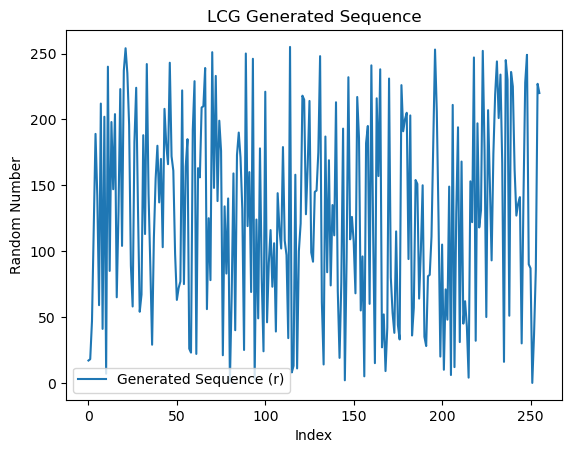

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
# Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) * 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi squsre test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()

## Discussion

In this lab, we explored the generation of pseudo-random numbers and the statistical validation of their randomness using the Chi-Square Test. We studied three common algorithms for random number generation — the Linear Congruential Generator (LCG), the XOR Shift Generator, and the Mersenne Twister — and focused on implementing the LCG due to its simplicity, low memory requirement, and faster computation.

The LCG formula, $X_{n+1} = (a \cdot X_n + c) \bmod m$, was used to generate the sequence of numbers, with careful selection of the multiplier ($a$), increment ($c$), and modulus ($m$) to ensure good statistical properties. A key part of the implementation was generating the seed ($X_0$) manually, without relying on any built-in random library. This was achieved by extracting system time components (hour, minute, second, millisecond), combining them arithmetically, and folding the result into the valid seed range using modulus.

We also observed the importance of *not* hardcoding a fixed seed value. A manually fixed seed makes the output sequence fully reproducible and predictable, defeating the purpose of randomness — it can lead to degenerate cycles in the generator, invalidate statistical testing across multiple runs, and pose serious risks in security-sensitive applications such as cryptography. Deriving the seed dynamically from system time ensured a different, unpredictable starting state on every execution.

Finally, the Chi-Square Test was applied to the generated numbers to statistically verify whether they followed a uniform distribution, by comparing the observed frequency ($O_i$) of values against the expected frequency ($E_i$) across defined intervals. A low Chi-Square value indicated that the generated sequence closely matched a uniform distribution, supporting the validity of the LCG implementation.

## Conclusion

This lab provided a hands-on understanding of how pseudo-random numbers are generated and validated. By implementing the Linear Congruential Generator from scratch — including manual seed computation without using any random library — we gained insight into the deterministic nature of pseudo-random generators and the critical role the seed plays in ensuring unpredictability. The Chi-Square Test further confirmed that the generated sequence satisfied the uniform distribution property expected of random numbers. Overall, the lab reinforced the theoretical concepts of randomness, seed-based state generation, and statistical validation, all of which are foundational to real-world applications such as cryptography, simulation, and machine learning.